## Lazy FCA classifier with interval pattern structures

In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Read the data & split train/test & preprocess

In [2]:
import pandas

data = pandas.read_csv("churn.csv")

data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [3]:
import sklearn.model_selection

X = data.drop(columns = ["Churn"])
y = (data["Churn"] == "Yes").to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 19), (704, 19), (6328,), (704,))

In [4]:
import sklearn.compose
import sklearn.preprocessing

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))

ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 39), (704, 39), (6328,), (704,))

In [5]:
X_train = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

X_train

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__Dependents_No,categorical__Dependents_Yes,categorical__StreamingTV_No,categorical__StreamingTV_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes,categorical__Partner_No,...,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No
0,3.0,55.80,154.55,True,False,True,False,False,True,False,...,True,False,True,False,True,False,False,True,False,False
1,10.0,19.80,198.25,True,False,True,False,False,True,True,...,True,False,True,False,False,True,False,False,False,True
2,49.0,106.65,5168.10,True,False,False,True,False,True,True,...,True,False,True,False,False,True,False,False,True,False
3,46.0,94.90,4422.95,True,False,False,True,False,True,True,...,True,False,True,False,False,True,False,False,True,False
4,10.0,19.95,187.75,True,False,True,False,False,True,False,...,True,False,True,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,36.0,92.90,3379.25,False,True,False,True,False,True,False,...,True,False,False,True,False,False,True,True,False,False
6324,10.0,65.90,660.05,False,True,True,False,False,True,False,...,True,False,True,False,False,True,False,True,False,False
6325,27.0,75.50,1893.95,True,False,True,False,False,True,False,...,False,True,True,False,True,False,False,False,True,False
6326,21.0,28.50,629.35,True,False,True,False,True,False,False,...,True,False,False,True,True,False,False,True,False,False


In [6]:
y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

y_train

0       False
1       False
2       False
3       False
4       False
        ...  
6323    False
6324    False
6325     True
6326    False
6327     True
Length: 6328, dtype: bool

#### Unchanged

In [ ]:
from typing import Any, List
import pandas as pd
import tqdm

class LazyClassifierFCA:
    def __init__(self):
        self.X_train = None
        self.y_train = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> None:
        self.X_train = X_train
        self.y_train = y_train
        
    def classify_sample(self, sample: pd.Series) -> Any:
        # Split X_train into positive and negative classes
        X_train_positive = self.X_train[y_train == 1]
        X_train_negative = self.X_train[y_train == 0]
        
        positive_classifiers = 0
        negative_classifiers = 0

        # Split the each part into binary and numerical
        binary_X_train_positive = X_train_positive.select_dtypes(include='bool')
        numerical_X_train_positive = X_train_positive.select_dtypes(exclude='bool')
        binary_X_train_negative = X_train_negative.select_dtypes(include='bool')
        numerical_X_train_negative = X_train_negative.select_dtypes(exclude='bool')
        
        
        def find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals):
            # Binary condition: Matches the binary intersection
            binary_positive_match = (binary_X_train_positive | ~binary_intersection).all(axis=1)
            binary_negative_match = (binary_X_train_negative | ~binary_intersection).all(axis=1)
    
            # Numerical condition: Lies within the intervals
            numerical_positive_match = numerical_X_train_positive.apply(
                lambda row: all(
                    interval[0] <= value <= interval[1] for value, interval in zip(row, numerical_intervals)
                ),
                axis=1
            )
            numerical_negative_match = numerical_X_train_negative.apply(
                lambda row: all(
                    interval[0] <= value <= interval[1] for value, interval in zip(row, numerical_intervals)
                ),
                axis=1
            )
            # print(f"pos_supp: \n {list(X_train_positive[(binary_positive_match & numerical_positive_match)].index)}")
            # print(f"neg_supp: \n {list(X_train_negative[(binary_negative_match & numerical_negative_match)].index)}")
            # Combine binary and numerical conditions
            num_positive = (binary_positive_match & numerical_positive_match).sum()
            num_negative = (binary_negative_match & numerical_negative_match).sum()
            return num_positive, num_negative
        
        # Function to check if intersection with a train sample is a positive classifier
        def is_positive_classifier(binary_intersection, numerical_intervals):
            num_positive, num_negative = find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals)
            return num_negative == 0 and num_positive > 1
        
        # Function to check if intersection is a negative classifier
        def is_negative_classifier(binary_intersection, numerical_intervals):
            num_positive, num_negative = find_number_of_positive_and_negative_matches(binary_intersection, numerical_intervals)
            return num_positive == 0 and num_negative > 1
        
        # Check for positive classifiers by intersecting sample with each positive object
        for _, pos_sample in X_train_positive.iterrows():
            # Binary intersection: AND operation
            binary_intersection = sample[binary_X_train_positive.columns] & pos_sample[binary_X_train_positive.columns]
            
            # Numerical intersection: Interval
            numerical_intersection = [
                (min(sample[col], pos_sample[col]), max(sample[col], pos_sample[col]))
                for col in numerical_X_train_positive.columns
            ]
            # print({sample.name}, {pos_sample.name})
            # print(f"{sample=}")
            # print(f"{pos_sample=}")
            # print(f"{binary_intersection=} \n {numerical_intersection=}")
            
            # Combine intersections and check
            if is_positive_classifier(binary_intersection, numerical_intersection):
                positive_classifiers += 1
        
        # Check for negative classifiers by intersecting sample with each negative object
        for _, neg_sample in X_train_negative.iterrows():
            # Binary intersection: AND operation
            binary_intersection = sample[binary_X_train_negative.columns] & neg_sample[binary_X_train_negative.columns]
            
            # Numerical intersection: Interval
            numerical_intersection = [
                (min(sample[col], neg_sample[col]), max(sample[col], neg_sample[col]))
                for col in numerical_X_train_negative.columns
            ]
            
            # Combine intersections and check
            if is_negative_classifier(binary_intersection, numerical_intersection):
                negative_classifiers += 1

        # Determine the class based on the number of classifiers
        if positive_classifiers > negative_classifiers:
            # print(f"sample {sample.name} is classified as 1, {positive_classifiers=}, {negative_classifiers=}")
            return 1  # Predict positive
            
        elif negative_classifiers > positive_classifiers:
            # print(f"sample {sample.name} is classified as 0, {positive_classifiers=}, {negative_classifiers=}")
            return 0  # Predict negative

        else:
            # If equal, you can decide on a rule, like defaulting to 0 or 1, or returning 'undetermined'
            # print(f"sample {sample.name} is classified as 1, default, {positive_classifiers=}, {negative_classifiers=}")
        
            return 1  # or 0, depending on the choice


    def predict(self, X_test: pd.DataFrame) -> List[Any]:
        # List to store predictions for each test sample
        predictions = []
        
        # Iterate through each sample in X_test
        for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test)):
            # Classify the sample and append the result to predictions
            prediction = self.classify_sample(sample)
            predictions.append(prediction)
        
        return predictions

In [8]:
classifier = LazyClassifierFCA()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

  0%|          | 2/704 [04:08<24:15:26, 124.40s/it]


KeyboardInterrupt: 

There is no way we are waiting an entire day for the predictions... Need to optimize. A lot.

#### Improved speed

- Replace slow `pandas` with fast `numpy` everywhere
- Use `joblib` to compute predictions for different objects in parallel
- Do as many calculations in `fit` as possible
- Vectorize the computations and remove `for` loops, especially nested.

In [9]:
import tqdm
import numpy
import typing
import joblib

class LazyClassifierFCA:
    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series):
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.bin_X_train_pos = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_pos = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.bin_X_train_neg = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_neg = X_train[y_train == 0][self.numeric_columns].to_numpy()


    def get_num_matches(
        self,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray
    ):
        bin_match = (bin_X_train | ~bin_int).all(axis = 1)
        num_match = ((num_int_min <= num_X_train) & (num_X_train <= num_int_max)).all(axis = 1)
        return (bin_match & num_match).sum()

    def find_matches_impl(self, bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray):
        num_positive = self.get_num_matches(self.bin_X_train_pos, self.num_X_train_pos, bin_int, num_int_min, num_int_max)
        num_negative = self.get_num_matches(self.bin_X_train_neg, self.num_X_train_neg, bin_int, num_int_min, num_int_max)
        return num_positive, num_negative

    def find_matches(self, sample_bin: numpy.ndarray, sample_num: numpy.ndarray, bin: numpy.ndarray, num: numpy.ndarray):
        num_stacked = numpy.vstack([ sample_num, num ])
        return self.find_matches_impl(sample_bin & bin, num_stacked.min(axis = 0), num_stacked.max(axis = 0))
    
    def get_number_of_classifiers(
        self,
        sample_bin: numpy.ndarray, sample_num: numpy.ndarray,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        is_classifier: typing.Callable[[int, int], bool]
    ):
        num_classifiers = 0
        for bin, num in zip(bin_X_train, num_X_train):
            if is_classifier(*self.find_matches(sample_bin, sample_num, bin, num)):
                num_classifiers += 1
        return num_classifiers
    
    def classify_sample(self, sample: pandas.Series):
        def is_positive_classifier(num_positive, num_negative):
            return num_negative == 0 and num_positive > 1
        
        def is_negative_classifier(num_positive, num_negative):
            return num_positive == 0 and num_negative > 1
        
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        positive_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_pos, self.num_X_train_pos, is_positive_classifier
        )
        negative_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_neg, self.num_X_train_neg, is_negative_classifier
        )
        
        if positive_classifiers > negative_classifiers:
            return 1
        elif negative_classifiers > positive_classifiers:
            return 0
        else:
            return 1


    def predict(self, X_test: pandas.DataFrame):
        return joblib.Parallel(n_jobs = -1)(
            joblib.delayed(self.classify_sample)(sample)
            for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
        )

In [10]:
classifier = LazyClassifierFCA()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

100%|██████████| 704/704 [06:17<00:00,  1.86it/s]


Much better. A day of calculations turned into 7 minutes. A 200x improvement.

{'Accuracy': 0.7755681818181818,
 'Precision': 0.7959183673469388,
 'Recall': 0.20855614973262032,
 'AUC-ROC': 0.5946068949823643,
 'F1-score': 0.3305084745762712,
 'True Positive': 39,
 'True Negative': 507,
 'False Positive': 10,
 'False Negative': 148,
 'True Negative Rate (Specificity)': 0.9806576402321083,
 'Negative Predictive Value': 0.7740458015267175,
 'False Positive Rate': 0.019342359767891684,
 'False Discovery Rate': 0.20408163265306123}

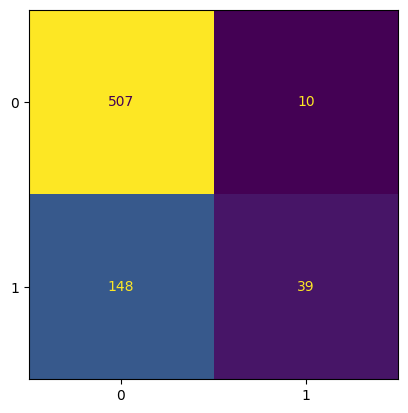

In [11]:
from utils import estimate_quality
import matplotlib.pyplot as plt

y_pred_proba = numpy.hstack([ numpy.reshape(y_pred, (-1, 1)) == 0, numpy.reshape(y_pred, (-1, 1)) == 1 ])

fig, axes = plt.subplots(1, 1)
estimate_quality(y_pred_proba, y_test, ax = axes)

#### Cache results

`get_num_matches` does a lot of expensive calculations which seem to be very repetitive. Intuition tells that there should be a very limited number of unique intersections of `sample` with objects from `train`. Caching the results after first calculations should improve the overall performance. Let's use redis for that.

In [12]:
import tqdm
import numpy
import redis
import typing
import joblib

class LazyClassifierFCA:
    def __init__(self, use_cache: bool = False, flush_cache: bool = False):
        self.use_cache = use_cache
        self.flush_cache = flush_cache

    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series):
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.bin_X_train_pos = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_pos = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.bin_X_train_neg = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_neg = X_train[y_train == 0][self.numeric_columns].to_numpy()


    def get_num_matches(
        self,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray
    ):
        bin_match = (bin_X_train | ~bin_int).all(axis = 1)
        num_match = ((num_int_min <= num_X_train) & (num_X_train <= num_int_max)).all(axis = 1)
        return (bin_match & num_match).sum()

    def find_matches_impl(self, bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray, cache):
        if cache:
            key = tuple([*bin_int, *num_int_min, *num_int_max]).__hash__()
            cached_val: bytes = cache.get(key)
            if cached_val:
                num_positive, num_negative = cached_val.split(b';')
                return int(num_positive), int(num_negative)
        num_positive = self.get_num_matches(self.bin_X_train_pos, self.num_X_train_pos, bin_int, num_int_min, num_int_max)
        num_negative = self.get_num_matches(self.bin_X_train_neg, self.num_X_train_neg, bin_int, num_int_min, num_int_max)
        if cache:
            cache.set(key, f"{num_positive};{num_negative}")
        return num_positive, num_negative

    def find_matches(self, sample_bin: numpy.ndarray, sample_num: numpy.ndarray, bin: numpy.ndarray, num: numpy.ndarray, cache):
        num_stacked = numpy.vstack([ sample_num, num ])
        return self.find_matches_impl(sample_bin & bin, num_stacked.min(axis = 0), num_stacked.max(axis = 0), cache)
    
    def get_number_of_classifiers(
        self,
        sample_bin: numpy.ndarray, sample_num: numpy.ndarray,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        is_classifier: typing.Callable[[int, int], bool]
    ):
        if self.use_cache:
            cache: redis.Redis = redis.Redis(host = 'localhost', port = 6379, db = 0)
        else:
            cache = None
        num_classifiers = 0
        for bin, num in zip(bin_X_train, num_X_train):
            if is_classifier(*self.find_matches(sample_bin, sample_num, bin, num, cache)):
                num_classifiers += 1
        return num_classifiers
    
    def classify_sample(self, sample: pandas.Series):
        def is_positive_classifier(num_positive, num_negative):
            return num_negative == 0 and num_positive > 1
        
        def is_negative_classifier(num_positive, num_negative):
            return num_positive == 0 and num_negative > 1
        
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        positive_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_pos, self.num_X_train_pos, is_positive_classifier
        )
        negative_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_neg, self.num_X_train_neg, is_negative_classifier
        )
        
        if positive_classifiers > negative_classifiers:
            return 1
        elif negative_classifiers > positive_classifiers:
            return 0
        else:
            return 1


    def predict(self, X_test: pandas.DataFrame):
        if self.use_cache and self.flush_cache:
            cache: redis.Redis = redis.Redis(host = 'localhost', port = 6379, db = 0)
            cache.flushdb()
            del cache
        return joblib.Parallel(n_jobs = -1)(
            joblib.delayed(self.classify_sample)(sample)
            for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
        )

In [13]:
classifier = LazyClassifierFCA(use_cache = True, flush_cache = True)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

100%|██████████| 704/704 [12:26<00:00,  1.06s/it]


{'Accuracy': 0.7755681818181818,
 'Precision': 0.7959183673469388,
 'Recall': 0.20855614973262032,
 'AUC-ROC': 0.5946068949823643,
 'F1-score': 0.3305084745762712,
 'True Positive': 39,
 'True Negative': 507,
 'False Positive': 10,
 'False Negative': 148,
 'True Negative Rate (Specificity)': 0.9806576402321083,
 'Negative Predictive Value': 0.7740458015267175,
 'False Positive Rate': 0.019342359767891684,
 'False Discovery Rate': 0.20408163265306123}

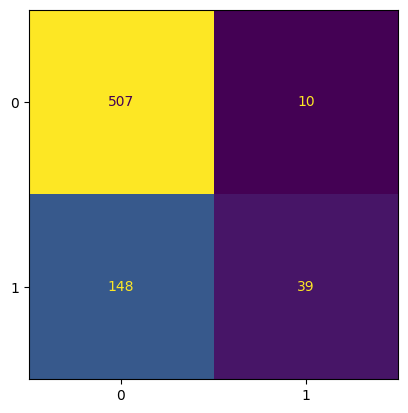

In [14]:
from utils import estimate_quality
y_pred_proba = numpy.hstack([ numpy.reshape(y_pred, (-1, 1)) == 0, numpy.reshape(y_pred, (-1, 1)) == 1 ])

fig, axes = plt.subplots(1, 1)
estimate_quality(y_pred_proba, y_test, ax = axes)

In [15]:
classifier = LazyClassifierFCA(use_cache = True)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

100%|██████████| 704/704 [02:24<00:00,  4.86it/s]


{'Accuracy': 0.7755681818181818,
 'Precision': 0.7959183673469388,
 'Recall': 0.20855614973262032,
 'AUC-ROC': 0.5946068949823643,
 'F1-score': 0.3305084745762712,
 'True Positive': 39,
 'True Negative': 507,
 'False Positive': 10,
 'False Negative': 148,
 'True Negative Rate (Specificity)': 0.9806576402321083,
 'Negative Predictive Value': 0.7740458015267175,
 'False Positive Rate': 0.019342359767891684,
 'False Discovery Rate': 0.20408163265306123}

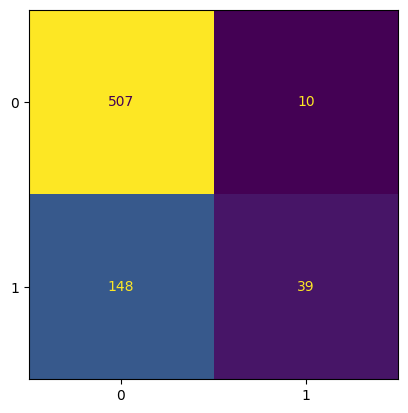

In [16]:
y_pred_proba = numpy.hstack([ numpy.reshape(y_pred, (-1, 1)) == 0, numpy.reshape(y_pred, (-1, 1)) == 1 ])

fig, axes = plt.subplots(1, 1)
estimate_quality(y_pred_proba, y_test, ax = axes)

In the first run, caching did not give the improvement we expected. Apparently, the extra costs to do caching outweigh the costs to actually compute some results multiple times. However, the second run, which operated solely from the cache, ran much faster.

So, this may be an interesting way to speed up the algorithm in production, or if we rewrite this in a good programming language that can efficiently work with shared memory unlike Python (to replace redis with an actual thread-shared variable). Unfortunately, this idea will not help us here. 

#### Improve F1-score

Let's introduce some parameters to the algorithm.
- To define positive classifiers:
    - `min_pos_for_pos_clas`: minimum number of supporters from positive class to consider the intersection a positive classifier
    - `pos_coef_for_pos_clas`: weight of supporters from positive class relative to the opposers from negative class
- To define negative classifiers:
    - `min_neg_for_neg_clas`: minimum number of supporters from negative class to consider the intersection a negative classifier
    - `neg_coef_for_neg_clas`: weight of supporters from negative class relative to the opposers from positive class
- To define the decision function:
    - `pos_clas_coef`: weight of positive classifiers relative to negative classifiers

In [17]:
import tqdm
import numpy
import typing
import joblib

class LazyClassifierFCA:
    def __init__(
        self,
        min_pos_for_pos_clas: int = 0, pos_coef_for_pos_clas: float = 1,
        min_neg_for_neg_clas: int = 0, neg_coef_for_neg_clas: float = 1,
        pos_clas_coef: float = 1
    ):
        self.min_pos_for_pos_clas = min_pos_for_pos_clas
        self.pos_coef_for_pos_clas = pos_coef_for_pos_clas
        self.min_neg_for_neg_clas = min_neg_for_neg_clas
        self.neg_coef_for_neg_clas = neg_coef_for_neg_clas
        self.pos_clas_coef = pos_clas_coef

    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series):
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.bin_X_train_pos = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_pos = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.bin_X_train_neg = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.num_X_train_neg = X_train[y_train == 0][self.numeric_columns].to_numpy()


    def get_num_matches(
        self,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray
    ):
        bin_match = (bin_X_train | ~bin_int).all(axis = 1)
        num_match = ((num_int_min <= num_X_train) & (num_X_train <= num_int_max)).all(axis = 1)
        return (bin_match & num_match).sum()

    def find_matches_impl(self, bin_int: numpy.ndarray, num_int_min: numpy.ndarray, num_int_max: numpy.ndarray):
        num_positive = self.get_num_matches(self.bin_X_train_pos, self.num_X_train_pos, bin_int, num_int_min, num_int_max)
        num_negative = self.get_num_matches(self.bin_X_train_neg, self.num_X_train_neg, bin_int, num_int_min, num_int_max)
        return num_positive, num_negative

    def find_matches(self, sample_bin: numpy.ndarray, sample_num: numpy.ndarray, bin: numpy.ndarray, num: numpy.ndarray):
        num_stacked = numpy.vstack([ sample_num, num ])
        return self.find_matches_impl(sample_bin & bin, num_stacked.min(axis = 0), num_stacked.max(axis = 0))
    
    def get_number_of_classifiers(
        self,
        sample_bin: numpy.ndarray, sample_num: numpy.ndarray,
        bin_X_train: numpy.ndarray, num_X_train: numpy.ndarray,
        is_classifier: typing.Callable[[int, int], bool]
    ):
        num_classifiers = 0
        for bin, num in zip(bin_X_train, num_X_train):
            if is_classifier(*self.find_matches(sample_bin, sample_num, bin, num)):
                num_classifiers += 1
        return num_classifiers
    
    def classify_sample(self, sample: pandas.Series):
        def is_positive_classifier(num_positive, num_negative):
            return self.pos_coef_for_pos_clas * num_positive > num_negative and num_positive >= self.min_pos_for_pos_clas
        
        def is_negative_classifier(num_positive, num_negative):
            return self.neg_coef_for_neg_clas * num_negative > num_positive and num_negative >= self.min_neg_for_neg_clas
        
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        positive_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_pos, self.num_X_train_pos, is_positive_classifier
        )
        negative_classifiers = self.get_number_of_classifiers(
            sample_bin, sample_num, self.bin_X_train_neg, self.num_X_train_neg, is_negative_classifier
        )

        positive_classifiers *= self.pos_clas_coef
        total = negative_classifiers + positive_classifiers
        return [ (negative_classifiers / total), (positive_classifiers / total) ]


    def predict(self, X_test: pandas.DataFrame):
        return numpy.array(
            joblib.Parallel(n_jobs = -1)(
                joblib.delayed(self.classify_sample)(sample)
                for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
            )
        )

Intuitively, makes sense to use the class imbalance (we have around 2.75 times more negative examples that positive ones) as weights of opposers and supporters when filtering classifiers.

In [18]:
classifier = LazyClassifierFCA(pos_coef_for_pos_clas = 2.75, neg_coef_for_neg_clas = 1.0 / 2.75)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

100%|██████████| 704/704 [06:33<00:00,  1.79it/s]


{'Accuracy': 0.7684659090909091,
 'Precision': 0.6395348837209303,
 'Recall': 0.29411764705882354,
 'AUC-ROC': 0.8271341242669038,
 'F1-score': 0.40293040293040294,
 'True Positive': 55,
 'True Negative': 486,
 'False Positive': 31,
 'False Negative': 132,
 'True Negative Rate (Specificity)': 0.9400386847195358,
 'Negative Predictive Value': 0.7864077669902912,
 'False Positive Rate': 0.059961315280464215,
 'False Discovery Rate': 0.36046511627906974}

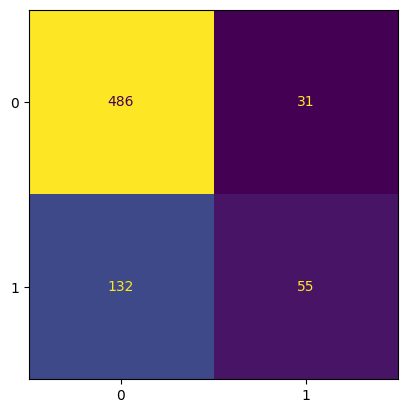

In [19]:
fig, axes = plt.subplots(1, 1)
estimate_quality(y_pred, y_test, ax = axes)

F1-score is slightly better now.

#### Search for hyperparameters

In [24]:
def process_sample(sample: pandas.Series):
    sample_bin = sample[classifier.bool_columns].to_numpy().astype(bool)
    sample_num = sample[classifier.numeric_columns].to_numpy()

    positive_classifiers_list = [
        classifier.find_matches(sample_bin, sample_num, pos_bin, pos_num)
        for pos_bin, pos_num in zip(classifier.bin_X_train_pos, classifier.num_X_train_pos)
    ]
    negative_classifiers_list = [
        classifier.find_matches(sample_bin, sample_num, neg_bin, neg_num)
        for neg_bin, neg_num in zip(classifier.bin_X_train_neg, classifier.num_X_train_neg)
    ]
    return positive_classifiers_list, negative_classifiers_list

classifier_lists = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process_sample)(sample)
    for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
)

100%|██████████| 704/704 [06:48<00:00,  1.72it/s]


In [25]:
import pickle

with open('classifier_lists.pkl', 'wb') as file:
    pickle.dump(classifier_lists, file)

In [ ]:
import itertools
min_pos_for_pos_clas_values = [0, 5, 10, 25, 50, 100, 250, 500]
pos_coef_for_pos_clas_values = [ 0.1, 0.25, 0.5, 0.75, 1.0, 2.5, 5.0, 7.5, 10.0 ]
min_neg_for_neg_clas_values = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 1500 ]
neg_coef_for_neg_clas_values = [ 0.1, 0.25, 0.5, 0.75, 1.0, 2.5, 5.0, 7.5, 10.0 ]
pos_clas_coef_values = [ 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0 ]
values = list(itertools.product(min_pos_for_pos_clas_values, pos_coef_for_pos_clas_values, min_neg_for_neg_clas_values, neg_coef_for_neg_clas_values, pos_clas_coef_values))

def process_params(min_pos_for_pos_clas, pos_coef_for_pos_clas, min_neg_for_neg_clas, neg_coef_for_neg_clas, pos_clas_coef):
    def is_positive_classifier(matches):
        num_positive, num_negative = matches
        return pos_coef_for_pos_clas * num_positive > num_negative and num_positive >= min_pos_for_pos_clas

    def is_negative_classifier(matches):
        num_positive, num_negative = matches
        return neg_coef_for_neg_clas * num_negative > num_positive and num_negative >= min_neg_for_neg_clas

    def make_pred(classifiers_lists):
        positive_classifiers_list, negative_classifiers_list = classifiers_lists
        positive_classifiers = sum(map(is_positive_classifier, positive_classifiers_list))
        negative_classifiers = sum(map(is_negative_classifier, negative_classifiers_list))

        positive_classifiers *= pos_clas_coef
        total = negative_classifiers + positive_classifiers
        if total == 0:
            return [0.5, 0.5]
        return [ (negative_classifiers / total), (positive_classifiers / total) ]

    with open('classifier_lists.pkl', 'rb') as f:
        classifier_lists = pickle.load(f)
    y_pred = list(map(make_pred, classifier_lists))
    metrics = estimate_quality(numpy.array(y_pred), y_test)
    return {
        'min_pos_for_pos_clas': min_pos_for_pos_clas,
        'pos_coef_for_pos_clas': pos_coef_for_pos_clas,
        'min_neg_for_neg_clas': min_neg_for_neg_clas,
        'neg_coef_for_neg_clas': neg_coef_for_neg_clas,
        'pos_clas_coef': pos_clas_coef,
        **metrics
    }

df_data = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process_params)(*params)
    for params in tqdm.tqdm(values)
)
df = pandas.DataFrame(df_data)
df.to_csv("selection_results.csv")
df

100%|██████████| 51840/51840 [10:57:04<00:00,  1.31it/s] 


,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,0,0.1,0,0.1,0.5,0.745739,0.785714,0.058824,0.789029,0.109453,11,514,3,176,0.994197,0.744928,0.005803,0.214286
1,0,0.1,0,0.1,1.0,0.758523,0.793103,0.122995,0.789029,0.212963,23,511,6,164,0.988395,0.757037,0.011605,0.206897
2,0,0.1,0,0.1,2.0,0.768466,0.671429,0.251337,0.789029,0.365759,47,494,23,140,0.955513,0.779180,0.044487,0.328571
3,0,0.1,0,0.1,2.5,0.772727,0.648352,0.315508,0.789029,0.424460,59,485,32,128,0.938104,0.791191,0.061896,0.351648
4,0,0.1,0,0.1,3.0,0.775568,0.630631,0.374332,0.789029,0.469799,70,476,41,117,0.920696,0.802698,0.079304,0.369369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51835,500,10.0,1500,10.0,2.5,0.654830,0.364078,0.401070,0.615480,0.381679,75,386,131,112,0.746615,0.775100,0.253385,0.635922
51836,500,10.0,1500,10.0,3.0,0.650568,0.358852,0.401070,0.611177,0.378788,75,383,134,112,0.740812,0.773737,0.259188,0.641148
51837,500,10.0,1500,10.0,3.5,0.649148,0.358491,0.406417,0.613256,0.380952,76,381,136,111,0.736944,0.774390,0.263056,0.641509
51838,500,10.0,1500,10.0,4.0,0.647727,0.356808,0.406417,0.611105,0.380000,76,380,137,111,0.735010,0.773931,0.264990,0.643192


In [ ]:
df.sort_values(by = 'F1-score', ascending = False).head(20)

,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
21030,25,0.50,10,0.10,4.0,0.785511,0.581081,0.689840,0.816863,0.630807,129,424,93,58,0.820116,0.879668,0.179884,0.418919
10233,5,2.50,10,0.25,1.0,0.755682,0.527076,0.780749,0.824259,0.629310,146,386,131,41,0.746615,0.903981,0.253385,0.472924
14478,10,0.50,5,0.10,4.0,0.775568,0.560669,0.716578,0.817603,0.629108,134,412,105,53,0.796905,0.886022,0.203095,0.439331
14547,10,0.50,10,0.10,2.5,0.776989,0.563559,0.711230,0.817297,0.628842,133,414,103,54,0.800774,0.884615,0.199226,0.436441
21916,25,0.75,50,0.75,3.0,0.769886,0.550201,0.732620,0.812472,0.628440,137,405,112,50,0.783366,0.890110,0.216634,0.449799
21676,25,0.75,5,0.10,3.0,0.765625,0.542969,0.743316,0.826524,0.627540,139,400,117,48,0.773694,0.892857,0.226306,0.457031
21098,25,0.50,25,0.10,2.0,0.778409,0.567100,0.700535,0.816796,0.626794,131,417,100,56,0.806576,0.881607,0.193424,0.432900
7996,5,0.50,5,0.10,3.0,0.769886,0.550607,0.727273,0.815642,0.626728,136,406,111,51,0.785300,0.888403,0.214700,0.449393
27811,50,0.50,250,0.50,2.5,0.764205,0.541176,0.737968,0.794893,0.624434,138,400,117,49,0.773694,0.890869,0.226306,0.458824
22394,25,1.00,5,0.10,2.0,0.764205,0.541176,0.737968,0.823379,0.624434,138,400,117,49,0.773694,0.890869,0.226306,0.458824


The seconds line looks the most reasonable and interpretable. Let's consider it more thoroughly and check the values in its vicinity.

In [ ]:
min_pos_for_pos_clas_values = [ 3, 4, 5, 6, 7 ]
pos_coef_for_pos_clas_values = [ 2.0, 2.25, 2.5, 2.75, 3.0 ]
min_neg_for_neg_clas_values = [ 7, 10, 13, 15, 17 ]
neg_coef_for_neg_clas_values = [ 0.15, 0.2, 0.25, 0.3, 0.35, 0.4 ]
pos_clas_coef_values = [ 0.5, 0.75, 1.0, 1.5, 2.0 ]
values = list(itertools.product(min_pos_for_pos_clas_values, pos_coef_for_pos_clas_values, min_neg_for_neg_clas_values, neg_coef_for_neg_clas_values, pos_clas_coef_values))

df2_data = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(process_params)(*params)
    for params in tqdm.tqdm(values)
)
df2 = pandas.DataFrame(df2_data)
df2.to_csv("selection_results_2.csv")
df2

100%|██████████| 3750/3750 [50:17<00:00,  1.24it/s]


,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,3,2.0,7,0.15,0.50,0.774148,0.574468,0.577540,0.826762,0.576000,108,437,80,79,0.845261,0.846899,0.154739,0.425532
1,3,2.0,7,0.15,0.75,0.752841,0.523297,0.780749,0.826762,0.626609,146,384,133,41,0.742747,0.903529,0.257253,0.476703
2,3,2.0,7,0.15,1.00,0.703125,0.466867,0.828877,0.826762,0.597303,155,340,177,32,0.657640,0.913978,0.342360,0.533133
3,3,2.0,7,0.15,1.50,0.620739,0.404306,0.903743,0.826762,0.558678,169,268,249,18,0.518375,0.937063,0.481625,0.595694
4,3,2.0,7,0.15,2.00,0.571023,0.379455,0.967914,0.826762,0.545181,181,221,296,6,0.427466,0.973568,0.572534,0.620545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,7,3.0,17,0.40,0.50,0.761364,0.711111,0.171123,0.813646,0.275862,32,504,13,155,0.974855,0.764795,0.025145,0.288889
3746,7,3.0,17,0.40,0.75,0.772727,0.613445,0.390374,0.813646,0.477124,73,471,46,114,0.911025,0.805128,0.088975,0.386555
3747,7,3.0,17,0.40,1.00,0.757102,0.536036,0.636364,0.813646,0.581907,119,414,103,68,0.800774,0.858921,0.199226,0.463964
3748,7,3.0,17,0.40,1.50,0.683239,0.447674,0.823529,0.813646,0.580038,154,327,190,33,0.632495,0.908333,0.367505,0.552326


In [ ]:
df2.sort_values(by = 'F1-score', ascending = False).head(20)

,min_pos_for_pos_clas,pos_coef_for_pos_clas,min_neg_for_neg_clas,neg_coef_for_neg_clas,pos_clas_coef,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
1992,5,2.75,10,0.25,1.00,0.755682,0.526502,0.796791,0.824072,0.634043,149,383,134,38,0.740812,0.909739,0.259188,0.473498
2142,5,3.00,10,0.25,1.00,0.754261,0.524648,0.796791,0.824166,0.632696,149,382,135,38,0.738878,0.909524,0.261122,0.475352
3522,7,2.75,13,0.25,1.00,0.752841,0.522807,0.796791,0.822728,0.631356,149,381,136,38,0.736944,0.909308,0.263056,0.477193
2107,5,3.00,7,0.20,1.00,0.755682,0.526882,0.786096,0.825614,0.630901,147,385,132,40,0.744681,0.905882,0.255319,0.473118
757,4,2.00,7,0.20,1.00,0.757102,0.528986,0.780749,0.825645,0.630670,146,387,130,41,0.748549,0.904206,0.251451,0.471014
36,3,2.00,10,0.20,0.75,0.758523,0.531136,0.775401,0.825055,0.630435,145,389,128,42,0.752418,0.902552,0.247582,0.468864
3672,7,3.00,13,0.25,1.00,0.751420,0.520979,0.796791,0.822795,0.630021,149,380,137,38,0.735010,0.909091,0.264990,0.479021
1086,4,2.50,10,0.20,0.75,0.762784,0.537879,0.759358,0.825236,0.629712,142,395,122,45,0.764023,0.897727,0.235977,0.462121
1842,5,2.50,10,0.25,1.00,0.755682,0.527076,0.780749,0.824259,0.629310,146,386,131,41,0.746615,0.903981,0.253385,0.472924
3396,7,2.50,15,0.20,0.75,0.755682,0.527076,0.780749,0.822842,0.629310,146,386,131,41,0.746615,0.903981,0.253385,0.472924


#### Best result

In [20]:
classifier = LazyClassifierFCA(
    min_pos_for_pos_clas = 5,
    pos_coef_for_pos_clas = 2.75,
    min_neg_for_neg_clas = 10,
    neg_coef_for_neg_clas = 0.25,
    pos_clas_coef = 1.0
)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

100%|██████████| 704/704 [06:25<00:00,  1.82it/s]


{'Accuracy': 0.7556818181818182,
 'Precision': 0.5265017667844523,
 'Recall': 0.7967914438502673,
 'AUC-ROC': 0.8240724459293125,
 'F1-score': 0.6340425531914894,
 'True Positive': 149,
 'True Negative': 383,
 'False Positive': 134,
 'False Negative': 38,
 'True Negative Rate (Specificity)': 0.7408123791102514,
 'Negative Predictive Value': 0.9097387173396675,
 'False Positive Rate': 0.25918762088974856,
 'False Discovery Rate': 0.4734982332155477}

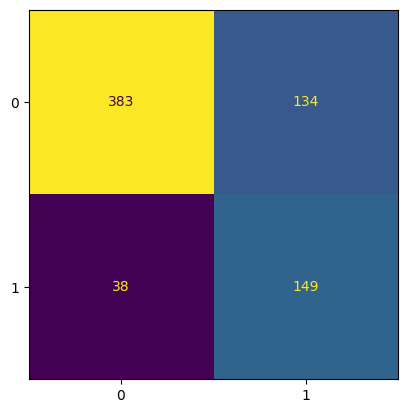

In [22]:
fig, axes = plt.subplots(1, 1)
estimate_quality(y_pred, y_test, ax = axes)